Gambaran Umum:

In [52]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
import plotly_express as px
import numpy as np

In [53]:
import datetime
import pandas as pd
import yfinance as yf

tickers = ['INCO.JK', 'SMGR.JK', 'ICBP.JK', 'BRPT.JK', 'MNCN.JK']

end_date = datetime.datetime(year=2025, month=12, day=8)
start_date = end_date - datetime.timedelta(days=5 * 365)

stock = pd.DataFrame()

for ticker in tickers:
    try:
        data = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            progress=False
        )

        if data.empty:
            print(f"[INFO] Tidak ada data untuk {ticker}")
            continue
        
        price_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'

        if price_col not in data.columns:
            print(f"[WARN] Kolom harga tidak ditemukan untuk {ticker}")
            continue

        if price_col == 'Close':
            print(f"[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk {ticker}")

        stock[ticker] = data[price_col]

    except Exception as e:
        print(f"[ERROR] Gagal mengambil data {ticker}: {e}")

print(stock.head())
stock.info()


[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk INCO.JK
[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk SMGR.JK
[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk ICBP.JK
[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk BRPT.JK
[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk MNCN.JK
                INCO.JK       SMGR.JK      ICBP.JK      BRPT.JK      MNCN.JK
Date                                                                        
2020-12-10  4840.527832  10110.306641  8914.844727  1176.332642  1032.527100
2020-12-11  5033.185547   9915.878906  8802.848633  1210.785889  1027.610352
2020-12-14  5081.350586  10369.546875  8802.848633  1225.551636  1042.360718
2020-12-15  5057.267578  10585.579102  8690.852539  1230.473511  1037.443848
2020-12-16  5298.089844  10888.023438  8758.051758  1240.317383  1175.114258
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1203 entries, 2020-12-10 to 2025-12-05
Data columns (total 5 columns):
 #   Column 

C:\Users\ACER\AppData\Local\Temp\ipykernel_20844\2365961395.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

C:\Users\ACER\AppData\Local\Temp\ipykernel_20844\2365961395.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

C:\Users\ACER\AppData\Local\Temp\ipykernel_20844\2365961395.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

C:\Users\ACER\AppData\Local\Temp\ipykernel_20844\2365961395.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

C:\Users\ACER\AppData\Local\Temp\ipykernel_20844\2365961395.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True



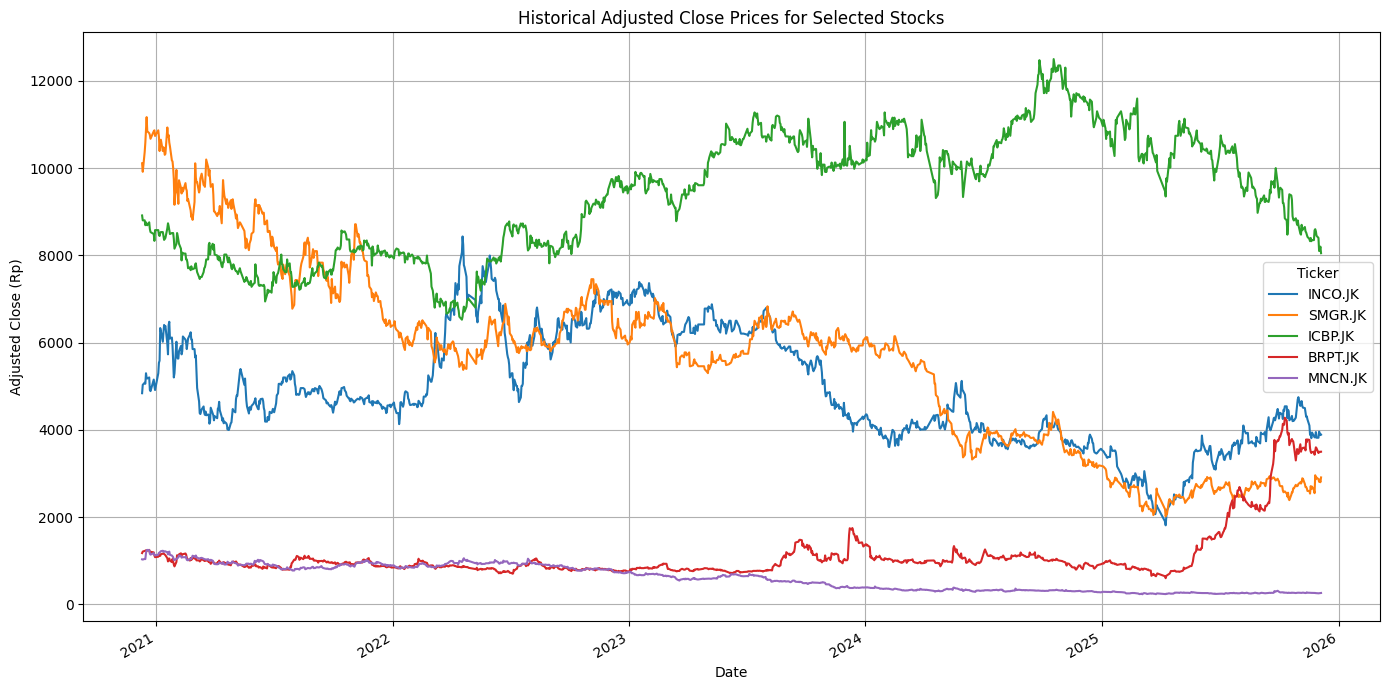

In [54]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))

ax = plt.gca()
stock.plot(ax=ax)

ax.set_title('Historical Adjusted Close Prices for Selected Stocks')
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Close (Rp)')
ax.legend(title='Ticker')
ax.grid(True)
plt.tight_layout()
plt.show()



In [55]:
print("Informasi Ringkas DataFrame stock:")
stock.info()

print("\nStatistik Deskriptif DataFrame stock:")
print(stock.describe())

print("\nJumlah Nilai Hilang per Kolom di stock:")
print(stock.isnull().sum())

Informasi Ringkas DataFrame stock:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1203 entries, 2020-12-10 to 2025-12-05
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   INCO.JK  1203 non-null   float64
 1   SMGR.JK  1203 non-null   float64
 2   ICBP.JK  1203 non-null   float64
 3   BRPT.JK  1203 non-null   float64
 4   MNCN.JK  1203 non-null   float64
dtypes: float64(5)
memory usage: 56.4 KB

Statistik Deskriptif DataFrame stock:
           INCO.JK       SMGR.JK       ICBP.JK      BRPT.JK      MNCN.JK
count  1203.000000   1203.000000   1203.000000  1203.000000  1203.000000
mean   4926.864139   5667.946874   9380.406787  1134.363095   612.297069
std    1282.956736   2116.737851   1377.137709   645.710334   291.847396
min    1812.706665   2017.924805   6525.930176   600.000000   232.000000
25%    3980.073242   3775.160645   8134.434082   828.562683   316.000000
50%    4637.290039   5918.951172   9550.000000   946.6271

In [78]:
import pandas as pd

daily_returns = stock.pct_change().dropna()

monthly_returns = (
    stock.resample('ME').last()
         .pct_change()
         .dropna()
)

normalized_stock_data = stock / stock.iloc[0]

print("\n=== Lima Baris Pertama Daily Returns ===")
print(daily_returns.head())

print("\n=== Lima Baris Pertama Monthly Returns ===")
print(monthly_returns.head())

print("\n=== Lima Baris Pertama Normalized Stock Data ===")
print(normalized_stock_data.head())



=== Lima Baris Pertama Daily Returns ===
             INCO.JK   SMGR.JK   ICBP.JK   BRPT.JK   MNCN.JK
Date                                                        
2020-12-11  0.039801 -0.019231 -0.012563  0.029289 -0.004762
2020-12-14  0.009569  0.045752  0.000000  0.012195  0.014354
2020-12-15 -0.004739  0.020833 -0.012723  0.004016 -0.004717
2020-12-16  0.047619  0.028571  0.007732  0.008000  0.132702
2020-12-17 -0.018182  0.025794 -0.005115  0.000000  0.054393

=== Lima Baris Pertama Monthly Returns ===
             INCO.JK   SMGR.JK   ICBP.JK   BRPT.JK   MNCN.JK
Date                                                        
2021-01-31  0.078431 -0.146881 -0.049608 -0.195455 -0.092105
2021-02-28  0.104546 -0.037736 -0.057692  0.242938  0.096618
2021-03-31 -0.279012  0.022059  0.072886 -0.127273 -0.158590
2021-04-30  0.052511  0.018530 -0.054348  0.041667  0.026178
2021-05-31  0.035498 -0.069544 -0.057471 -0.097205 -0.056122

=== Lima Baris Pertama Normalized Stock Data ===
          

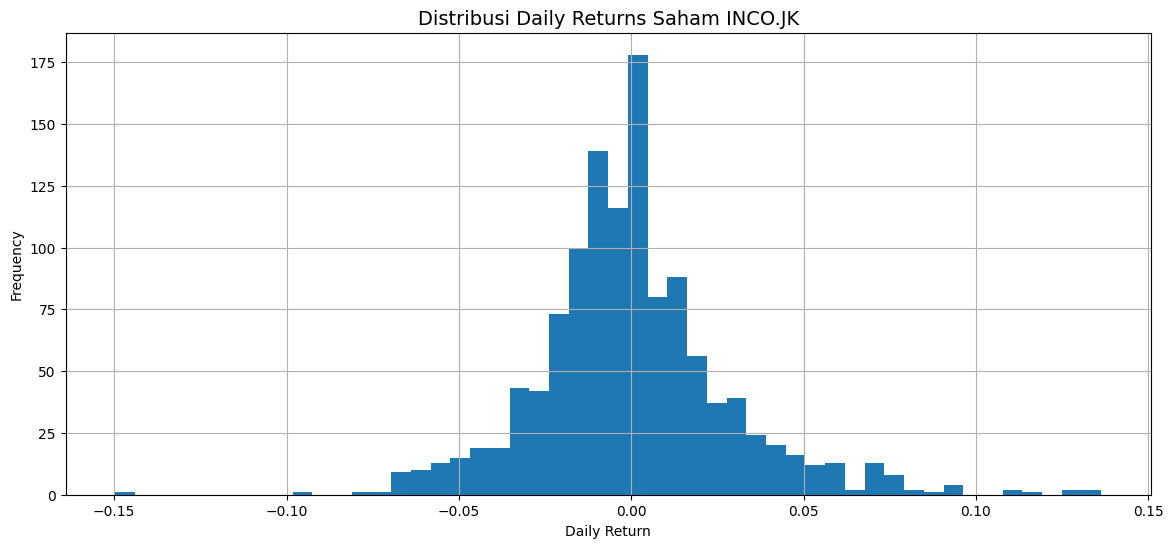

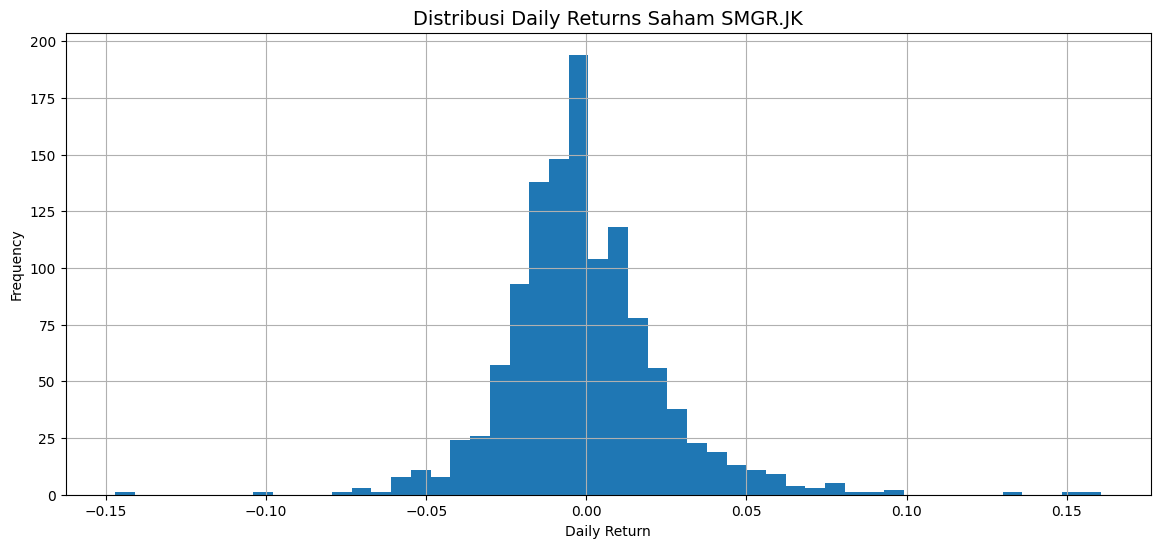

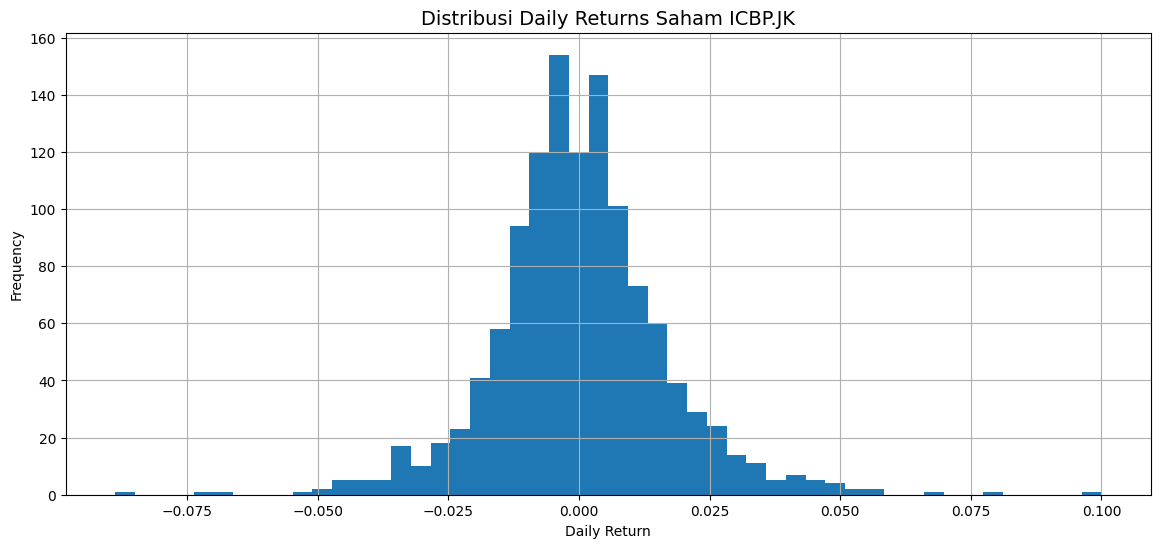

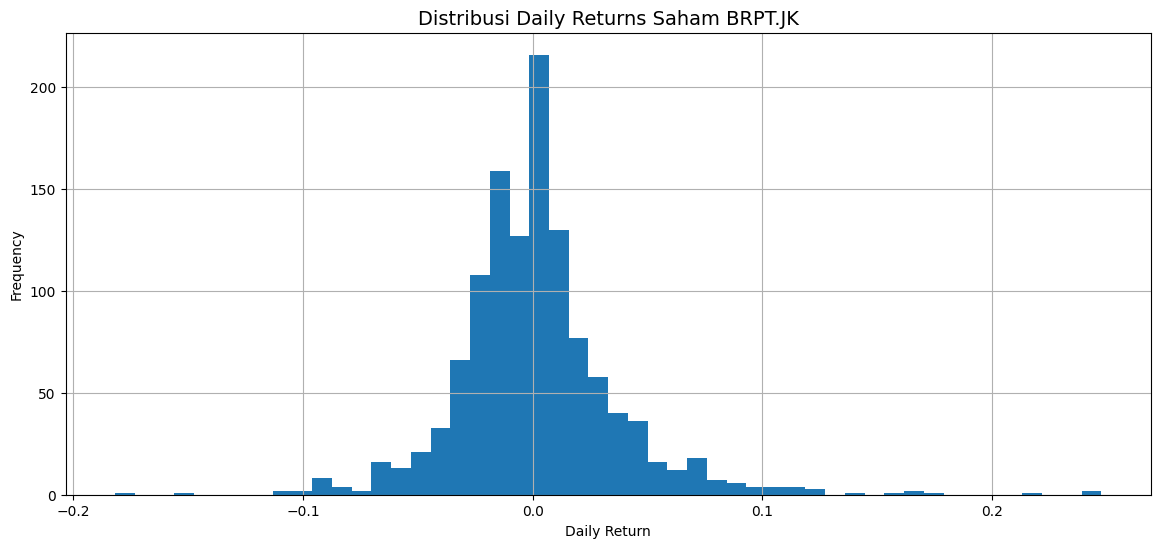

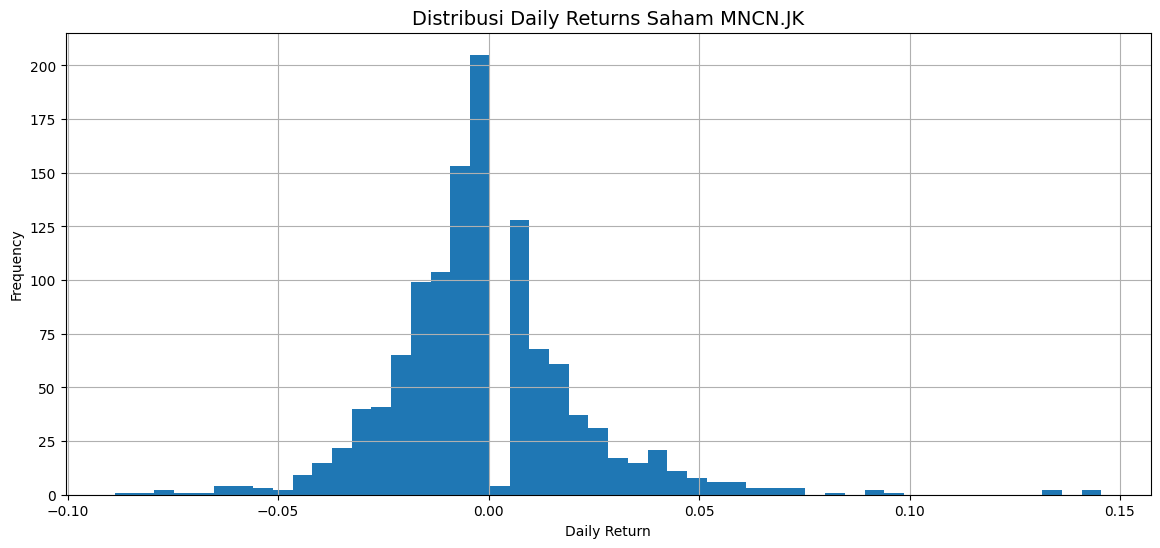

Histograms untuk daily returns telah ditampilkan.


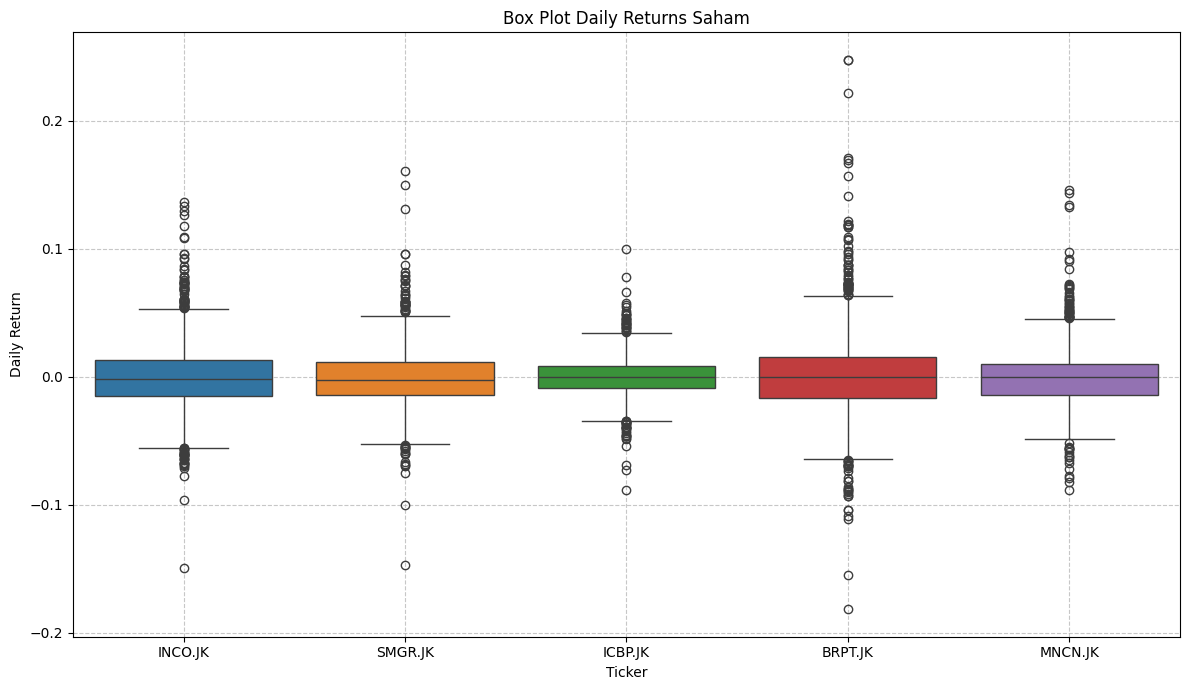

Box plots untuk daily returns telah ditampilkan.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt

for column in daily_returns.columns:
    
    fig, ax = plt.subplots(figsize=(14, 6)) 

    daily_returns[column].hist(bins=50, ax=ax)

    ax.set_title(f'Distribusi Daily Returns Saham {column}', fontsize=14)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
    
    plt.show() 

print("Histograms untuk daily returns telah ditampilkan.")

plt.figure(figsize=(12, 7))
plt.title('Box Plot Daily Returns Saham')
sns.boxplot(data=daily_returns)
plt.xlabel('Ticker')
plt.ylabel('Daily Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("Box plots untuk daily returns telah ditampilkan.")

In [ ]:
import plotly_express as px

fig_normalized_prices = px.line(
    normalized_stock_data,
    x=normalized_stock_data.index,
    y=normalized_stock_data.columns,
    title='Perbandingan Harga Saham yang Dinormalisasi (Interaktif)',
    labels={'index': 'Tanggal', 'value': 'Harga Dinormalisasi'},
    hover_name=normalized_stock_data.columns.name 
)

fig_normalized_prices.update_layout(
    xaxis_title='Tanggal',
    yaxis_title='Harga Dinormalisasi'
)

fig_normalized_prices.show()

print("Line plot interaktif untuk harga saham yang dinormalisasi telah ditampilkan.")

Line plot interaktif untuk harga saham yang dinormalisasi telah ditampilkan.


In [ ]:
import plotly_express as px

print("Membuat histogram interaktif untuk daily returns setiap saham...")

for col in daily_returns.columns:
    fig_hist_daily_returns = px.histogram(
        daily_returns,
        x=col,
        nbins=50, # Number of bins
        title=f'Distribusi Daily Returns Interaktif untuk {col}',
        labels={col: 'Daily Return', 'count': 'Frekuensi'}
    )
    fig_hist_daily_returns.update_layout(xaxis_title='Daily Return', yaxis_title='Frekuensi')
    fig_hist_daily_returns.show()
print("Histogram interaktif untuk daily returns telah ditampilkan.")

Membuat histogram interaktif untuk daily returns setiap saham...


Histogram interaktif untuk daily returns telah ditampilkan.


In [ ]:
import datetime
TRADING_DAYS_PER_YEAR = 252
RISK_FREE_RATE = 0.01

cumulative_returns = (1 + daily_returns).prod() - 1

annual_returns = daily_returns.mean() * TRADING_DAYS_PER_YEAR

annualized_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

sharpe_ratios = (annual_returns - RISK_FREE_RATE) / annualized_volatility

portfolio_metrics = pd.DataFrame({
    'Cumulative Return': cumulative_returns,
    'Annual Return': annual_returns,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratios
})

print("Metrik Portofolio untuk Setiap Saham:")
print(portfolio_metrics.round(4))

Metrik Portofolio untuk Setiap Saham:
         Cumulative Return  Annual Return  Annualized Volatility  Sharpe Ratio
INCO.JK            -0.1964         0.0548                 0.4511        0.0994
SMGR.JK            -0.7122        -0.1870                 0.3866       -0.5095
ICBP.JK            -0.0970         0.0127                 0.2616        0.0105
BRPT.JK             1.9753         0.3888                 0.5727        0.6615
MNCN.JK            -0.7463        -0.2196                 0.3706       -0.6196


In [71]:
import numpy as np

num_assets = len(tickers)
weights = np.array([1/num_assets] * num_assets)

weights_df = pd.Series(weights, index=daily_returns.columns)

portfolio_daily_returns = daily_returns.dot(weights)

print("Lima Baris Pertama Daily Returns Portofolio:")
print(portfolio_daily_returns.head())

Lima Baris Pertama Daily Returns Portofolio:
Date
2020-12-11    0.006507
2020-12-14    0.016374
2020-12-15    0.000534
2020-12-16    0.044925
2020-12-17    0.011378
dtype: float64


In [72]:
import numpy as np

portfolio_cumulative_return = (1 + portfolio_daily_returns).prod() - 1

portfolio_annual_return = portfolio_daily_returns.mean() * TRADING_DAYS_PER_YEAR

portfolio_annualized_volatility = portfolio_daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

portfolio_sharpe_ratio = (portfolio_annual_return - RISK_FREE_RATE) / portfolio_annualized_volatility

print("\nMetrik Keseluruhan Portofolio (Bobot Sama):")
print(f"Cumulative Return: {portfolio_cumulative_return:.4f}")
print(f"Annual Return: {portfolio_annual_return:.4f}")
print(f"Annualized Volatility: {portfolio_annualized_volatility:.4f}")
print(f"Sharpe Ratio: {portfolio_sharpe_ratio:.4f}")


Metrik Keseluruhan Portofolio (Bobot Sama):
Cumulative Return: -0.0828
Annual Return: 0.0100
Annualized Volatility: 0.2372
Sharpe Ratio: -0.0002


In [76]:
import numpy as np
import pandas as pd

np.random.seed(42)

num_portfolios = 10000

portfolio_returns = []
portfolio_volatility = []
portfolio_sharpe_ratios = []
portfolio_weights = []

num_assets = len(daily_returns.columns)
mean_daily_returns = daily_returns.mean()
cov_matrix_daily = daily_returns.cov()

for portfolio in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights)

    portfolio_weights.append(weights)

    annual_returns_individual = mean_daily_returns * TRADING_DAYS_PER_YEAR
    portfolio_annual_return = np.sum(annual_returns_individual * weights)
    portfolio_returns.append(portfolio_annual_return)

    portfolio_annual_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_daily * TRADING_DAYS_PER_YEAR, weights)))
    portfolio_volatility.append(portfolio_annual_volatility)

    sharpe_ratio = (portfolio_annual_return - RISK_FREE_RATE) / portfolio_annual_volatility
    portfolio_sharpe_ratios.append(sharpe_ratio)

portfolio_results = pd.DataFrame({
    'Return': portfolio_returns,
    'Volatility': portfolio_volatility,
    'Sharpe Ratio': portfolio_sharpe_ratios
})

for i, col in enumerate(daily_returns.columns):
    portfolio_results[col + ' Weight'] = [w[i] for w in portfolio_weights]

print("Lima baris pertama hasil simulasi portofolio:")
print(portfolio_results.head())

optimal_portfolio = portfolio_results.loc[portfolio_results['Sharpe Ratio'].idxmax()]
min_volatility_portfolio = portfolio_results.loc[portfolio_results['Volatility'].idxmin()]

print("\n======================================================")
print("Portofolio Optimal (Sharpe Ratio Tertinggi):")
print("------------------------------------------------------")
print(f"Annual Return: {optimal_portfolio['Return']:.4f}")
print(f"Annualized Volatility: {optimal_portfolio['Volatility']:.4f}")
print(f"Sharpe Ratio: {optimal_portfolio['Sharpe Ratio']:.4f}")
print("Weights:")
for col in daily_returns.columns:
    print(f"  {col}: {optimal_portfolio[col + ' Weight']:.4f}")
print("======================================================")

print("\n======================================================")
print("Portofolio Risiko Minimum:")
print("------------------------------------------------------")
print(f"Annual Return: {min_volatility_portfolio['Return']:.4f}")
print(f"Annualized Volatility: {min_volatility_portfolio['Volatility']:.4f}")
print(f"Sharpe Ratio: {min_volatility_portfolio['Sharpe Ratio']:.4f}")
print("Weights:")
for col in daily_returns.columns:
    print(f"  {col}: {min_volatility_portfolio[col + ' Weight']:.4f}")
print("======================================================")

Lima baris pertama hasil simulasi portofolio:
     Return  Volatility  Sharpe Ratio  INCO.JK Weight  SMGR.JK Weight  \
0  0.017997    0.242743      0.032945        0.133197        0.338101   
1  0.036384    0.238588      0.110584        0.065285        0.024308   
2 -0.057273    0.238557     -0.281999        0.009284        0.437468   
3  0.036784    0.235526      0.113719        0.105673        0.175297   
4  0.028654    0.255146      0.073111        0.327909        0.074759   

   ICBP.JK Weight  BRPT.JK Weight  MNCN.JK Weight  
0        0.260318        0.212900        0.055485  
1        0.362501        0.251571        0.296334  
2        0.375464        0.095773        0.082010  
3        0.302353        0.248877        0.167800  
4        0.156568        0.196343        0.244421  

Portofolio Optimal (Sharpe Ratio Tertinggi):
------------------------------------------------------
Annual Return: 0.2745
Annualized Volatility: 0.4200
Sharpe Ratio: 0.6299
Weights:
  INCO.JK: 0.1580
  

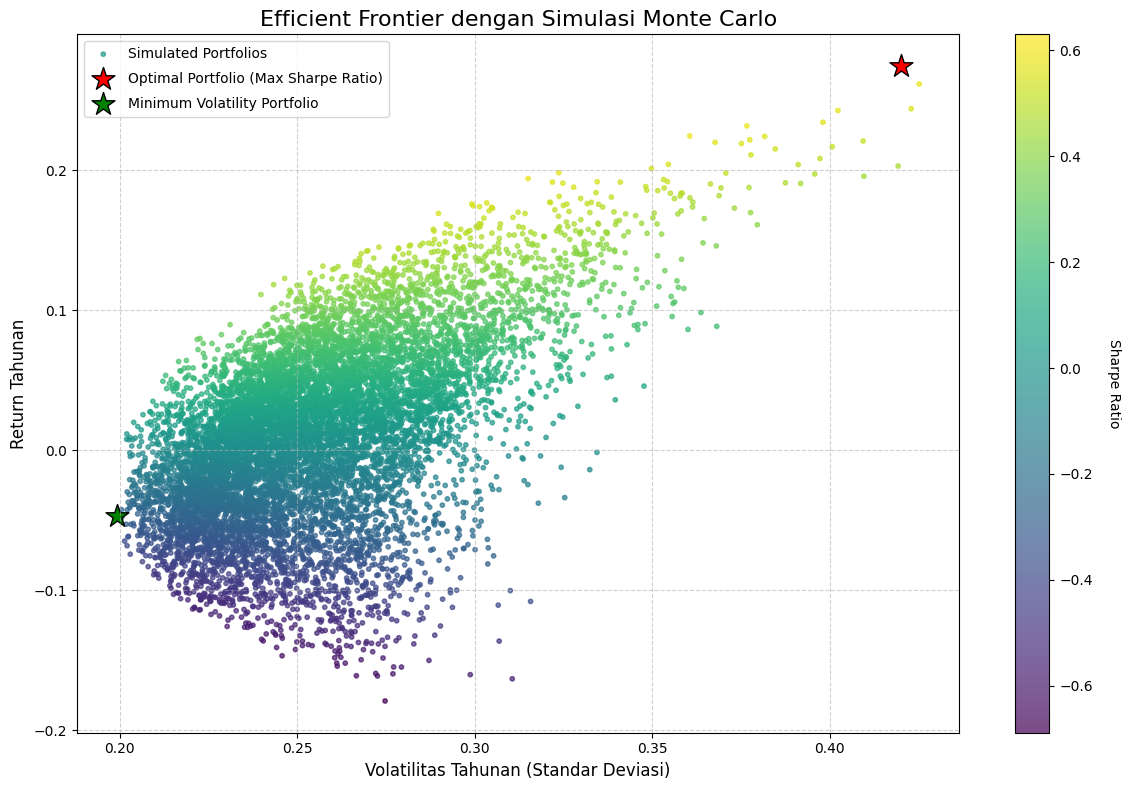

Scatter plot hasil simulasi portofolio telah ditampilkan.


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    portfolio_results['Volatility'],
    portfolio_results['Return'],
    c=portfolio_results['Sharpe Ratio'], 
    cmap='viridis',
    marker='o',
    s=10,
    alpha=0.7,
    label='Simulated Portfolios'
)

plt.scatter(
    optimal_portfolio['Volatility'],
    optimal_portfolio['Return'],
    marker='*',  
    color='red',
    s=300,
    label='Optimal Portfolio (Max Sharpe Ratio)',
    edgecolors='black',
    linewidth=1
)

plt.scatter(
    min_volatility_portfolio['Volatility'],
    min_volatility_portfolio['Return'],
    marker='*', 
    color='green',
    s=300,
    label='Minimum Volatility Portfolio',
    edgecolors='black',
    linewidth=1
)

plt.title('Efficient Frontier dengan Simulasi Monte Carlo', fontsize=16)
plt.xlabel('Volatilitas Tahunan (Standar Deviasi)', fontsize=12)
plt.ylabel('Return Tahunan', fontsize=12)

plt.legend(labelspacing=0.8, loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

print("Scatter plot hasil simulasi portofolio telah ditampilkan.")

## Penjelasan Konsep Metrik 
*Setelah melakukan beberapa diskusi dan analisis metrik portofolio, kita mendapatkan beberapa data yaitu return kumulatif, return tahunan rata-rata, volatilitas/risiko (standar deviasi return tahunan), dan rasio Sharpe.*

### Definisi dan Interpretasi
* **Cumulative Return**
    Digunakan untuk mengukur total perubahan nilai investasi sejak periode awal hingga periode akhir dengan memajemukan return harian yang ada. Metode ini merupakan langkah sederhana untuk melihat seberapa besar investasi telah tumbuh atau menyusut secara keseluruhan. Ketika tanda adalah negatif, berarti perubaha nilai mengalami kerugian.
    Rumus: `(1 + return_harian_1) * (1 + return_harian_2) * ... * (1 + return_harian_n) - 1` atau `(Harga Akhir / Harga Awal) - 1`
*   Cumulative Return pada INCO.JK bisa kita hitung dengan mengkalikan seluruh (1 + Ri​) lalu dikurangi 1
*   Jika Cumulative Return < 0, maka investasi mengalami kerugian. Sebaliknya jika Cumulative Return > 0, maka investasi mengalami keuntungan, 
1. INCO.JK memiliki nilai minus di -0.1729 yang menandakan aset kehilangan sekitar 17.29% dari nilai awal
2. SMGR.JK memiliki nilai minus di -0.7290 yang menandakan aset kehilangan sekitar 72.9% dari nilai awal
3. ICBP.JK memiliki nilai minus di -0.0982 yang menandakan aset kehilangan sekitar 9.82% dari nilai awal
4. BRPT.JK memiliki nilai positif di 2.1650 yang menandakan aset bertambah sekitar 216.5% dari nilai awal
5. MNCN.JK memiliki nilai minus di -0.2291 yang menandakan aset kehilangan sekitar 22.91% dari nilai awal

#### **Kesimpulan**
*	BRPT.JK adalah aset dengan kinerja terbaik yang jauh melampaui aset lainnya, mencatat pertumbuhan sebesar +216.50%. Ini berarti investasi awal pada BRPT.JK telah tumbuh lebih dari tiga kali lipat (faktor pertumbuhan 3.165) selama periode yang dianalisis.

*	Sebanyak 4 dari 5 aset (80%) mencatat Cumulative Return negatif (kerugian). Meskipun BRPT.JK menunjukkan pertumbuhan luar biasa, mayoritas aset berkinerja buruk dalam hal nilai absolut.


### Definisi dan Interpretasi
* **Annual Return**
    Rata-rata tingkat pengembalian yang diperoleh dalam setahun. Dapat dipergunakan dalam menilai hasil investasi dengan jangka waktu yang berbeda. Metrik ini melakukan normalisasi return dari periode apa pun ke skala tahunan.
    Rumus (Rata-rata Aritmetika yang di-annualisasi): `rata_rata_return_harian * jumlah_hari_perdagangan`

Annual Return dari kelima saham tersebut beserta kesimpulan :
1. INCO.JK memiliki annual return sebesar 0.0609 (+6.09%) yang berati saham ini rata-rata menghasilkan keuntungan tahunan kecil namun positif. Meski cumulative return negatif, kinerja tahunan cenderung pulih atau stabil.
2. SMGR.JK memiliki annual return sebesar -0.1941 (-19.41%) yang berati saham ini mengalami penurunan signifikan setiap tahun. Saham ini menunjukkan tren melemah pada periode data.
3. ICBP.JK memiliki annual return sebesar 0.0140 (+1.40%) yang berati pertumbuhan tahunan saham ini sangat kecil namun tetap positif. Ini menunjukkan saham relatif stabil dengan fluktuasi rendah.
4. BRPT.JK memiliki annual return sebesar 0.4032 (+40.32%) yang berati pertumbuhan tahunan saham ini sangat tinggi. Ini adalah saham dengan kinerja terbaik dalam kelompok ini dan memberikan return paling agresif.
5. MNCN.JK memiliki annual return sebesar -0.2283 (-22.83%) yang berati saham ini memiliki penurunan tahunan yang besar, menunjukkan tren kinerja yang memburuk selama periode analisis.
Kesimpulan
* BRPT.JK memiliki annual return tertinggi, dengan pertumbuhan sekitar 40% per tahun, menunjukkan performa sangat baik dan potensi keuntungan tinggi.
* INCO.JK dan ICBP.JK mencatat annual return positif, meskipun berada pada level sedang-cenderung rendah, mengindikasikan stabilitas tetapi bukan pertumbuhan signifikan.
* SMGR.JK dan MNCN.JK memiliki annual return negatif cukup besar, mencerminkan penurunan kinerja perusahaan dari waktu ke waktu dan risiko kerugian jika dipegang dalam jangka panjang.

### Definisi dan Interpretasi
* **Annualize Volatility / Risiko**
    Pengukur besar fluktuasi harga aset atau portofolio dalam setahun. Metode ini menjadi penanda risiko dengan rincian semakin tinggi volatilitas, maka semakin besar risiko yang terkait dengan aset tersebut. Dihitung sebagai standar deviasi return yang di-annualisasi.
    Rumus: `Standar Deviasi Harian Return * sqrt(jumlah_hari_perdagangan)`
	Standar Absolut (Aturan Umum / Rule of Thumb):

* *Volatilitas Rendah (< 20%): Pergerakan harga stabil, jarang memberikan kejutan.*
* *Volatilitas Sedang (20% - 40%): Pergerakan harga cukup dinamis mengikuti siklus pasar, ada potensi naik/turun yang wajar.*
* *Volatilitas Tinggi (> 40%): "Liar". Harga bisa melonjak atau anjlok puluhan persen dalam waktu singkat.*

Standar absolute ini didapatkan dari benchmark historis pasar dan praktik industri keuangan untuk mengklasifikasikan risiko saham.Jadi standar ini didapatkan dari kombinasi antara data historis pasar, distribusi volatilitas saham, dan praktik umum lembaga keuangan.
Angka Annualized Volatility pada 5 Saham 
1. Pada saham INCO.JK ini memiliki angka volatilitas yang mencapai pada angka 45% yang menunjukkan bahwa pergerakan harga saham tersebut cukup liar.
2. Pada saham SMGR.JK , angka volatilitas saham tersebut menyentuh angka 38%, yang menandakan bahwa pergerakan harga saham tersebut sangat dinamis.
3. Pada saham ICBP.JK ,ini memiliki angka volatilitas yang termasuk dalam kategori sedang, yakni pada angka 26% , yang menunjukkan bahwa pergerakan saham ini relatif dinamis.
4. Pada saham BRPT.JK memiliki angka volatilitas yang sangat tinggi , yakni mencapai 57%.Angka tersebut mencerminkan bahwa pergerakan harga saham ini sangat ekstrem.
5. Pada Saham MNCN.JK ,angka volatilitasnya mencapai 37% yang mengindikasikan bahwa pergerakan harga saham tersebut sangat dinamis karena berada angka volatilitas tersebut berada pada rentang yang dianggap volatilitas sedang dalam aturan umum.

Kesimpulan 
Secara keseluruhan,  saham-saham yang dianalisis ini memiliki profil risiko yang cenderung agresif dan dinamis. Tidak ada saham yang benar-benar "pasif" atau bervolatilitas rendah (di bawah 20%) .Dari lima saham yang dianalisis, sebagian besar menunjukkan tingkat volatilitas yang tinggi. BRPT.JK memiliki volatilitas tertinggi (57%) diikuti INCO.JK (45%), keduanya menunjukkan pergerakan harga yang sangat liar. SMGR.JK (38%) dan MNCN.JK (37%) tergolong cukup dinamis dengan fluktuasi harga yang kuat mengikuti pasar. Sementara itu, ICBP.JK memiliki volatilitas paling rendah (26%) sehingga pergerakannya lebih stabil dibanding saham lainnya.


### Definisi dan Interpretasi
* **Sharpe Ratio**
    Digunakan untuk evaluasi kinerja investasi dengan pertimbangan risiko yang di punya. Rasio ini mengukur kelebihan pengembalian (return di atas tingkat bebas risiko) per unit risiko. Semakin tinggi Rasio Sharpe, semakin baik pengembalian investasi dibandingkan dengan risiko yang diambil
    Rumus: `(Annual Return - Risk-Free Rate) / Annualized Volatility`

Sharpe Ratio bisa kita hitung dengan mengurangi Annual Return dengan Risk-Free Rate lalu dibagi dengan Annualized Volatility.
1. INCO.JK memiliki Sharpe Ratio sebesar 0.11 yang berarti kita mendapat return ekstra sebesar 0.11% untuk setiap 1% resiko yang diambil.
2. SMGR.JK memiliki Sharpe Ratio sebesar -0.54 yang berarti kita mendapat return ekstra sebesar -0.54% untuk setiap 1% resiko yang diambil.
3. ICBP.JK memiliki Sharpe Ratio sebesar 0.0094 yang berarti kita mendapat return ekstra sebesar 0.0094% untuk setiap 1% resiko yang diambil.
4. BRPT.JK memiliki Sharpe Ratio sebesar 0.68 yang berarti kita mendapat return ekstra sebesar 0.68% untuk setiap 1% resiko yang diambil.
5. MNCN.JK memiliki Sharpe Ratio sebesar -0.64 yang berarti kita mendapat return ekstra sebesar -0.64% untuk setiap 1% resiko yang diambil.

Kesimpulan
	BRPT.JK: Merupakan pilihan investasi yang paling efisien di antara kelima saham ini. Untuk setiap 1% risiko yang diambil, investor mendapatkan 0.68% return ekstra. Ini berarti return yang diperoleh sangat sebanding dengan risiko yang ditanggung.
Sebaliknya, dalam proses alokasi aset saham seperti SMGR.JK (-0.54 ) dan MNCN.JK (-0.64 ) harus dihindari karena return yang diperoleh tidak sebanding dengan risiko yang ditanggung

